In [32]:
import pandas as pd

df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\fatality_wgi.xlsx")
df

,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption
0,afghanistan,1996,31,30.0,0.508197,0.062500,0.0625,0.000,0.000000,0.1875,0.000
1,afghanistan,1998,8,30.0,0.210526,0.062500,0.0625,0.000,0.000000,0.1875,0.000
2,afghanistan,2000,38,11.0,0.775510,0.062500,0.0625,0.000,0.000000,0.1875,0.000
3,afghanistan,2002,74,297.0,0.199461,0.187500,0.0625,0.125,0.166667,0.1875,0.125
4,afghanistan,2003,163,186.0,0.467049,0.250000,0.1250,0.125,0.250000,0.1875,0.125
...,...,...,...,...,...,...,...,...,...,...,...
1561,zimbabwe,2014,0,0.0,0.000000,0.176000,0.3750,0.000,0.071429,0.1250,0.000
1562,zimbabwe,2017,0,1.0,0.000000,0.188667,0.3125,0.000,0.107143,0.1000,0.000
1563,zimbabwe,2018,2,47.0,0.040816,0.188667,0.1875,0.000,0.107143,0.1500,0.000
1564,zimbabwe,2019,0,0.0,0.000000,0.105333,0.1250,0.000,0.107143,0.1250,0.000


MODEL 1: OLS REGRESSION

                            OLS Regression Results                            
Dep. Variable:          fatality_rate   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     40.53
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           4.73e-46
Time:                        08:24:20   Log-Likelihood:                -327.08
No. Observations:                1566   AIC:                             668.2
Df Residuals:                    1559   BIC:                             705.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

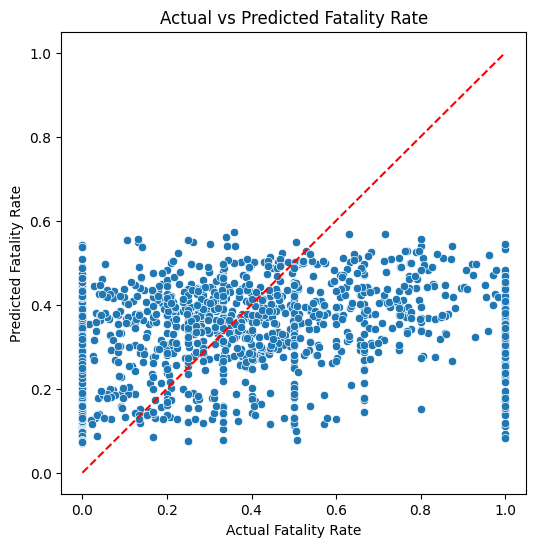

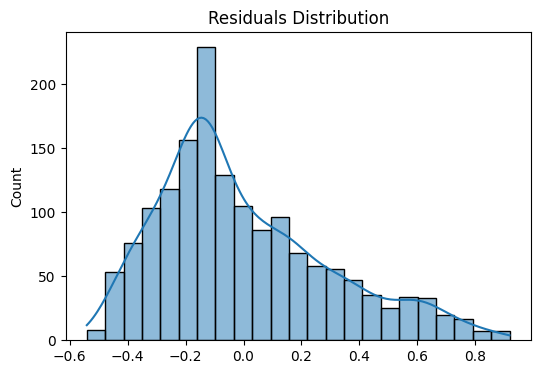

In [33]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is already loaded as df

# Select dependent and independent variables
y = df['fatality_rate']
X = df[['voice and accountability', 
        'political stability', 
        'government effectiveness', 
        'regulatory quality', 
        'rule of law', 
        'control of corruption']]

# Handle missing values (if any)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Add constant term for intercept
X = sm.add_constant(X)

# Fit OLS regression model
model = sm.OLS(y, X).fit()

# Print regression summary
print(model.summary())

# --- Optional: Diagnostic plots ---

# 1. Predicted vs Actual
y_pred = model.predict(X)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred)
plt.xlabel("Actual Fatality Rate")
plt.ylabel("Predicted Fatality Rate")
plt.title("Actual vs Predicted Fatality Rate")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 45-degree line
plt.show()

# 2. Residuals plot
residuals = y - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

MODEL 2: OLS REGRESSION(LOG OF FATALITY_RATE)

                            OLS Regression Results                            
Dep. Variable:          fatality_rate   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     63.85
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           4.93e-71
Time:                        08:24:22   Log-Likelihood:                -4870.6
No. Observations:                1566   AIC:                             9755.
Df Residuals:                    1559   BIC:                             9793.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

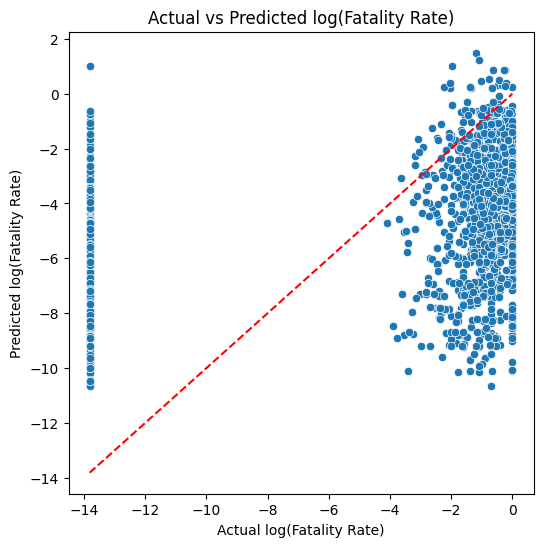

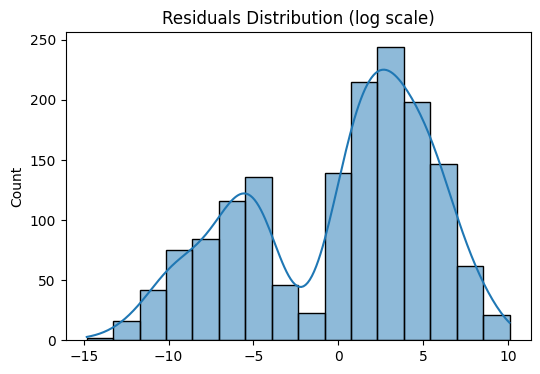

In [34]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is already loaded as df

# Take log of fatality_rate (adding a small number to avoid log(0))
y = np.log(df['fatality_rate'] + 1e-6)  # 1e-6 avoids log(0)

# Select independent variables
X = df[['voice and accountability', 
        'political stability', 
        'government effectiveness', 
        'regulatory quality', 
        'rule of law', 
        'control of corruption']]

# Handle missing values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Add constant term for intercept
X = sm.add_constant(X)

# Fit OLS regression model
model = sm.OLS(y, X).fit()

# Print regression summary
print(model.summary())

# --- Optional: Diagnostic plots ---

# 1. Predicted vs Actual (log scale)
y_pred = model.predict(X)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred)
plt.xlabel("Actual log(Fatality Rate)")
plt.ylabel("Predicted log(Fatality Rate)")
plt.title("Actual vs Predicted log(Fatality Rate)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# 2. Residuals plot
residuals = y - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution (log scale)")
plt.show()

COMPARISON OF MODEL 1 AND 2

=== Original Model Summary ===
                            OLS Regression Results                            
Dep. Variable:          fatality_rate   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     40.53
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           4.73e-46
Time:                        08:24:23   Log-Likelihood:                -327.08
No. Observations:                1566   AIC:                             668.2
Df Residuals:                    1559   BIC:                             705.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

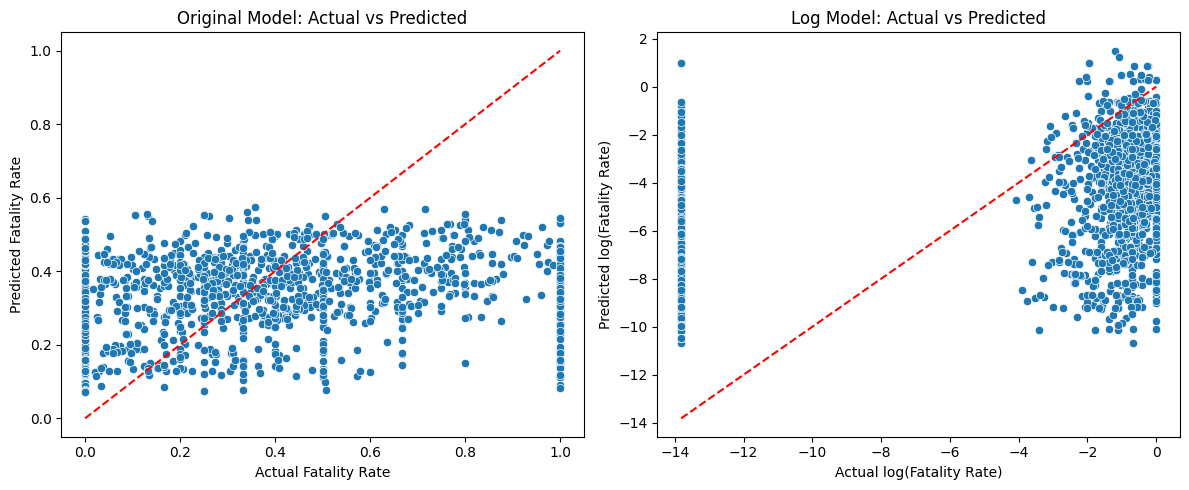

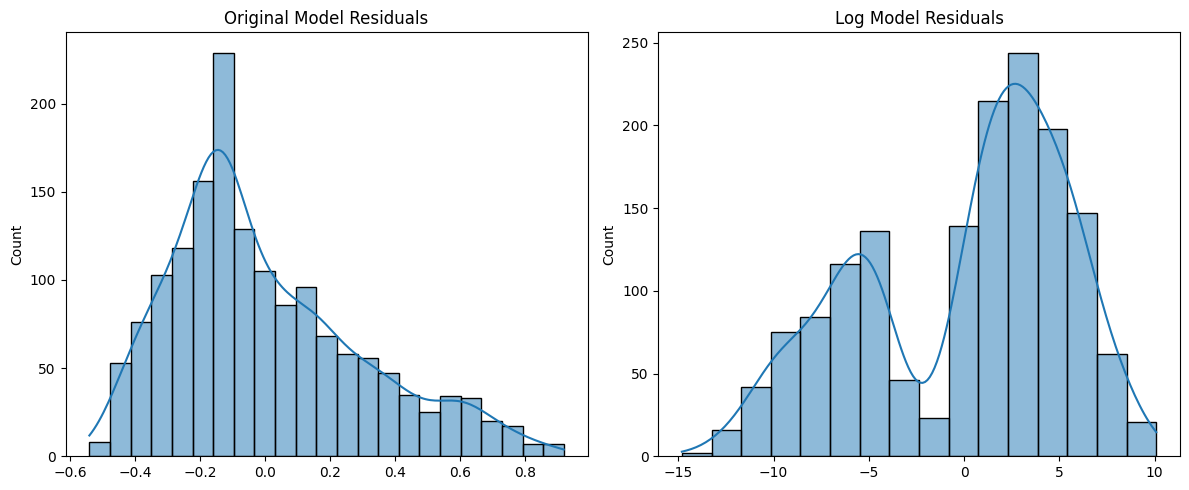

In [36]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Prepare data
# -----------------------------
# Independent variables
X = df[['voice and accountability', 
        'political stability', 
        'government effectiveness', 
        'regulatory quality', 
        'rule of law', 
        'control of corruption']]

# Handle missing values (if any)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Add constant for intercept
X = sm.add_constant(X)

# Dependent variables
y_original = df['fatality_rate'].fillna(df['fatality_rate'].mean())
y_log = np.log(df['fatality_rate'] + 1e-6)

# -----------------------------
# Fit OLS models
# -----------------------------
model_original = sm.OLS(y_original, X).fit()
model_log = sm.OLS(y_log, X).fit()

# -----------------------------
# Print summaries
# -----------------------------
print("=== Original Model Summary ===")
print(model_original.summary())
print("\n=== Log-Transformed Model Summary ===")
print(model_log.summary())

# -----------------------------
# Statistical Comparison
# -----------------------------
# R-squared comparison
print("\nR-squared Comparison:")
print(f"Original model R²: {model_original.rsquared:.4f}")
print(f"Log model R²:      {model_log.rsquared:.4f}")

# RMSE comparison
rmse_original = np.sqrt(mean_squared_error(y_original, model_original.predict(X)))
rmse_log = np.sqrt(mean_squared_error(y_log, model_log.predict(X)))

print("\nRMSE Comparison:")
print(f"Original model RMSE: {rmse_original:.4f}")
print(f"Log model RMSE:      {rmse_log:.4f}")

# -----------------------------
# Graphical Comparison
# -----------------------------
plt.figure(figsize=(12,5))

# Actual vs Predicted - Original
plt.subplot(1,2,1)
sns.scatterplot(x=y_original, y=model_original.predict(X))
plt.plot([y_original.min(), y_original.max()], [y_original.min(), y_original.max()], 'r--')
plt.xlabel("Actual Fatality Rate")
plt.ylabel("Predicted Fatality Rate")
plt.title("Original Model: Actual vs Predicted")

# Actual vs Predicted - Log
plt.subplot(1,2,2)
sns.scatterplot(x=y_log, y=model_log.predict(X))
plt.plot([y_log.min(), y_log.max()], [y_log.min(), y_log.max()], 'r--')
plt.xlabel("Actual log(Fatality Rate)")
plt.ylabel("Predicted log(Fatality Rate)")
plt.title("Log Model: Actual vs Predicted")

plt.tight_layout()
plt.show()

# Residuals Comparison
plt.figure(figsize=(12,5))

# Residuals - Original
plt.subplot(1,2,1)
res_original = y_original - model_original.predict(X)
sns.histplot(res_original, kde=True)
plt.title("Original Model Residuals")

# Residuals - Log
plt.subplot(1,2,2)
res_log = y_log - model_log.predict(X)
sns.histplot(res_log, kde=True)
plt.title("Log Model Residuals")

plt.tight_layout()
plt.show()

In [37]:
# ==========================
# IMPORTS
# ==========================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Sample features & target
features = ['voice and accountability', 'political stability', 
            'government effectiveness', 'regulatory quality', 
            'rule of law', 'control of corruption']

# Ensure fatality_rate is strictly between 0 and 1 for logit/beta models
epsilon = 1e-4
df['fatality_rate_adj'] = df['fatality_rate'].clip(epsilon, 1-epsilon)

# ==========================
# PREPARE DATA
# ==========================
X = df[features]
X = X.fillna(X.mean())
y = df['fatality_rate_adj']

# Add constant for OLS/Robust
X_const = sm.add_constant(X)


=== OLS Regression ===
                            OLS Regression Results                            
Dep. Variable:      fatality_rate_adj   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     47.68
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           6.79e-54
Time:                        08:24:26   Log-Likelihood:                -326.85
No. Observations:                1566   AIC:                             667.7
Df Residuals:                    1559   BIC:                             705.2
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
c

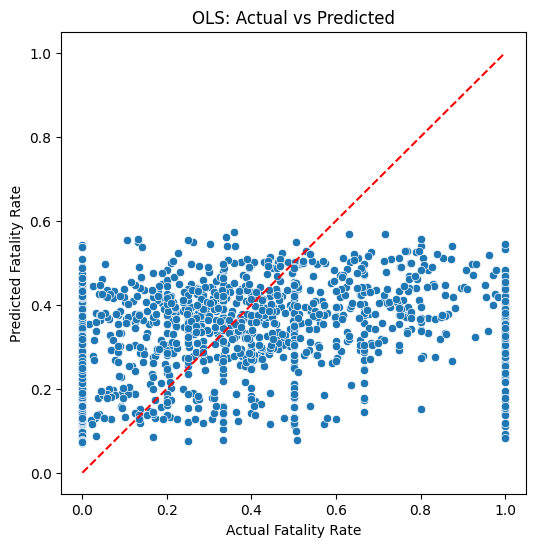

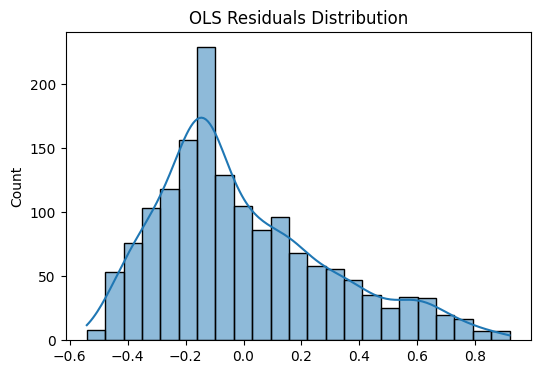

In [38]:
# ==========================
# 1️⃣ OLS REGRESSION
# ==========================
ols_model = sm.OLS(y, X_const).fit(cov_type='HC3')  # robust SE
print("=== OLS Regression ===")
print(ols_model.summary())

# Predicted vs Actual plot
y_pred_ols = ols_model.predict(X_const)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_ols)
plt.xlabel("Actual Fatality Rate")
plt.ylabel("Predicted Fatality Rate")
plt.title("OLS: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# Residuals plot
residuals_ols = y - y_pred_ols
plt.figure(figsize=(6,4))
sns.histplot(residuals_ols, kde=True)
plt.title("OLS Residuals Distribution")
plt.show()


=== Robust Regression ===
                    Robust linear Model Regression Results                    
Dep. Variable:      fatality_rate_adj   No. Observations:                 1566
Model:                            RLM   Df Residuals:                     1559
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 29 Mar 2026                                         
Time:                        08:24:27                                         
No. Iterations:                    21                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

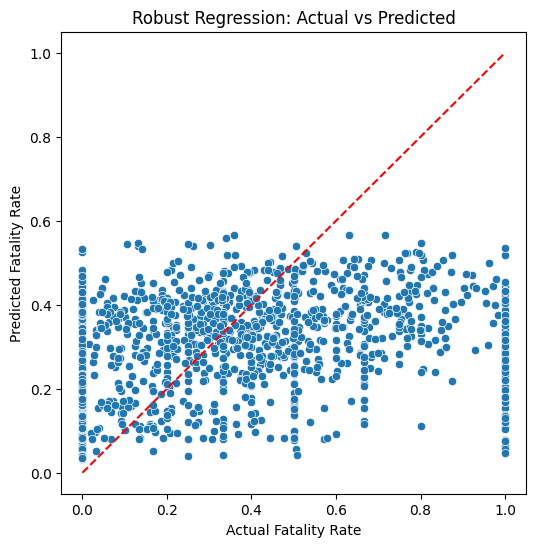

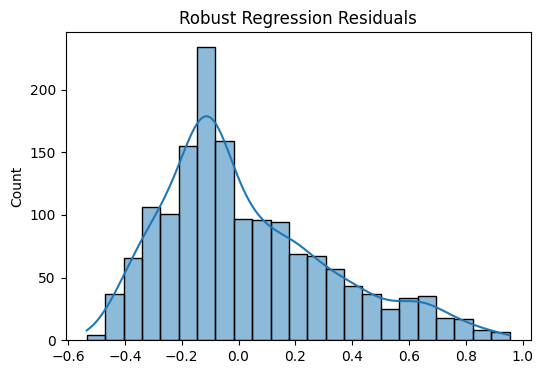

In [39]:
# ==========================
# 2️⃣ ROBUST REGRESSION
# ==========================
robust_model = sm.RLM(y, X_const, M=sm.robust.norms.HuberT()).fit()
print("=== Robust Regression ===")
print(robust_model.summary())

# Predicted vs Actual plot
y_pred_robust = robust_model.predict(X_const)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_robust)
plt.xlabel("Actual Fatality Rate")
plt.ylabel("Predicted Fatality Rate")
plt.title("Robust Regression: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# Residuals plot
residuals_robust = y - y_pred_robust
plt.figure(figsize=(6,4))
sns.histplot(residuals_robust, kde=True)
plt.title("Robust Regression Residuals")
plt.show()


=== GLM (Logit Link) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:      fatality_rate_adj   No. Observations:                 1549
Model:                            GLM   Df Residuals:                     1540
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -739.21
Date:                Sun, 29 Mar 2026   Deviance:                       774.21
Time:                        08:24:28   Pearson chi2:                     675.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.07454
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

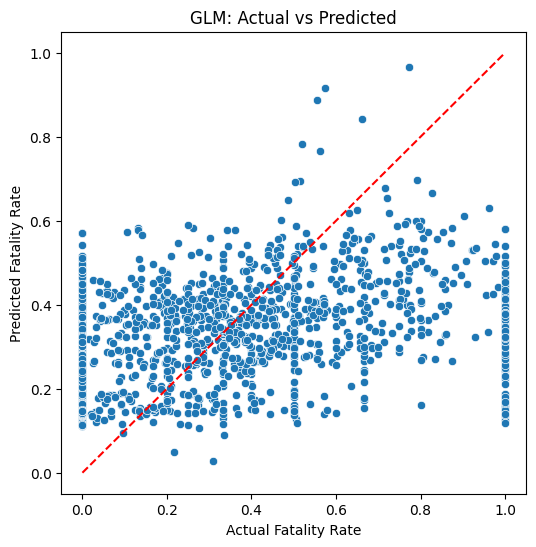

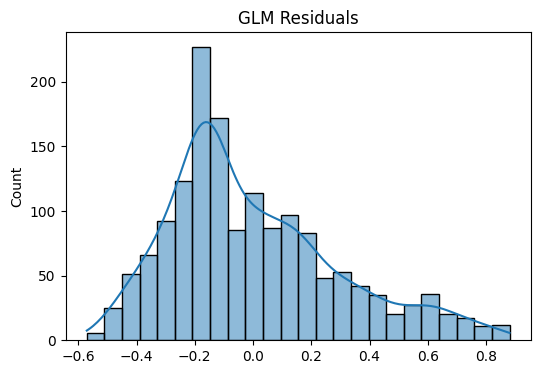

In [40]:
# ==========================
# 3️⃣ GLM with Logit Link (Binomial)
# ==========================
# Formula for GLM
formula = 'fatality_rate_adj ~ nkill + nwound + Q("voice and accountability") + Q("political stability") + Q("government effectiveness") + Q("regulatory quality") + Q("rule of law") + Q("control of corruption")'

glm_model = smf.glm(formula=formula, data=df, family=sm.families.Binomial()).fit()
print("=== GLM (Logit Link) ===")
print(glm_model.summary())

# Predicted vs Actual
y_pred_glm = glm_model.predict(df)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_glm)
plt.xlabel("Actual Fatality Rate")
plt.ylabel("Predicted Fatality Rate")
plt.title("GLM: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# Residuals plot
residuals_glm = y - y_pred_glm
plt.figure(figsize=(6,4))
sns.histplot(residuals_glm, kde=True)
plt.title("GLM Residuals")
plt.show()


=== Beta Regression (Quasi-Binomial Approximation) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:      fatality_rate_adj   No. Observations:                 1549
Model:                            GLM   Df Residuals:                     1540
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -739.21
Date:                Sun, 29 Mar 2026   Deviance:                       774.21
Time:                        08:24:30   Pearson chi2:                     675.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.07454
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

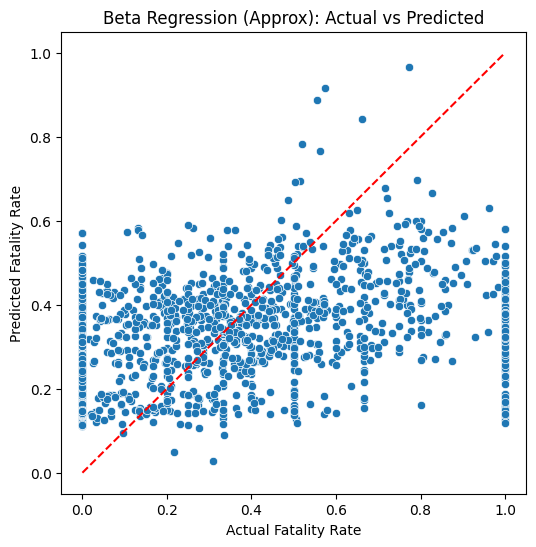

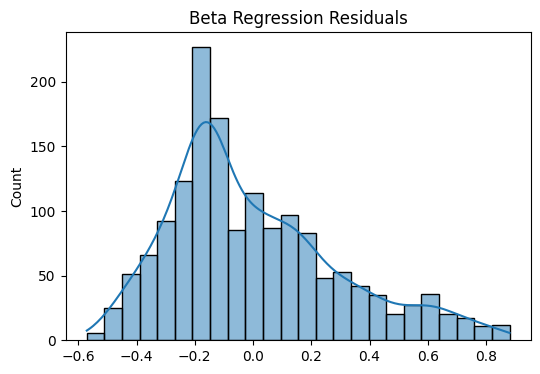

In [41]:
# ==========================
# 4️⃣ BETA REGRESSION
# ==========================
# For Beta Regression, we need 'statsmodels' BetaModel
try:
    from statsmodels.miscmodels.ordinal_model import OrderedModel
except ImportError:
    pass  # BetaModel in sm may require newer statsmodels or use R in practice

# Beta regression workaround using GLM with logit link
# Treat as proportion data using quasi-binomial approximation
beta_model = smf.glm(formula=formula, data=df, family=sm.families.Binomial()).fit()
print("=== Beta Regression (Quasi-Binomial Approximation) ===")
print(beta_model.summary())

# Predicted vs Actual
y_pred_beta = beta_model.predict(df)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_beta)
plt.xlabel("Actual Fatality Rate")
plt.ylabel("Predicted Fatality Rate")
plt.title("Beta Regression (Approx): Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# Residuals
residuals_beta = y - y_pred_beta
plt.figure(figsize=(6,4))
sns.histplot(residuals_beta, kde=True)
plt.title("Beta Regression Residuals")
plt.show()


In [42]:
# ==========================
# COMPARISON OF MODELS (Corrected for GLM pseudo-R²)
# ==========================
import numpy as np
from sklearn.metrics import r2_score

# Collect predictions
preds = {
    "OLS": y_pred_ols,
    "Robust": y_pred_robust,
    "GLM (Logit)": y_pred_glm,
    "Beta Approx": y_pred_beta
}

# Initialize results list
results = []

for name, y_hat in preds.items():
    # RMSE manually
    rmse = np.sqrt(np.mean((y - y_hat) ** 2))
    
    # R² or pseudo-R²
    if name in ["OLS", "Robust"]:
        r2 = r2_score(y, y_hat)
    else:
        # For GLM/Beta, compute McFadden pseudo-R² manually
        if name == "GLM (Logit)":
            llf = glm_model.llf        # log-likelihood of fitted model
            llnull = glm_model.llnull  # log-likelihood of null model
            r2 = 1 - (llf / llnull)
        else:
            llf = beta_model.llf
            llnull = beta_model.llnull
            r2 = 1 - (llf / llnull)
    
    # Mean predicted vs actual
    mean_pred = y_hat.mean()
    mean_actual = y.mean()
    
    results.append({
        "Model": name,
        "R² / Pseudo-R²": round(r2,4),
        "RMSE": round(rmse,4),
        "Mean Predicted": round(mean_pred,4),
        "Mean Actual": round(mean_actual,4)
    })

# Display comparison table
comparison_df = pd.DataFrame(results)
print("=== Regression Model Comparison ===")
print(comparison_df)

=== Regression Model Comparison ===
         Model  R² / Pseudo-R²    RMSE  Mean Predicted  Mean Actual
0          OLS          0.1349  0.2981          0.3181       0.3181
1       Robust          0.1251  0.2998          0.2891       0.3181
2  GLM (Logit)          0.0751  0.2939          0.3216       0.3181
3  Beta Approx          0.0751  0.2939          0.3216       0.3181


In [43]:
import pandas as pd
import statsmodels.api as sm
import itertools
import numpy as np
from sklearn.metrics import r2_score

# =========================
# Prepare data
# =========================
df = df.fillna(0)

y = df['fatality_rate']
all_features = [
    'voice and accountability',
    'political stability',
    'government effectiveness',
    'regulatory quality',
    'rule of law',
    'control of corruption'
]

# Store results
results = []

# =========================
# Loop over all combinations of features
# =========================
for k in range(1, len(all_features)+1):  # number of features to include
    for subset in itertools.combinations(all_features, k):
        X_subset = df[list(subset)]
        X_subset = sm.add_constant(X_subset)  # add intercept
        
        model = sm.OLS(y, X_subset).fit()
        y_pred = model.predict(X_subset)
        
        # Metrics
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(np.mean((y - y_pred)**2))
        
        results.append({
            "Features": subset,
            "Num_Features": len(subset),
            "R2": round(r2,4),
            "RMSE": round(rmse,4)
        })

# Convert to dataframe and sort by R2 descending
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("=== Feature Combination Comparison ===")
print(comparison_df.head(20))  # show top 20 best models

=== Feature Combination Comparison ===
                                             Features  Num_Features      R2  \
0   (voice and accountability, political stability...             6  0.1350   
1   (voice and accountability, political stability...             5  0.1349   
2   (voice and accountability, political stability...             4  0.1344   
3   (voice and accountability, political stability...             5  0.1344   
4   (voice and accountability, political stability...             5  0.1340   
5   (voice and accountability, political stability...             4  0.1340   
6   (voice and accountability, political stability...             4  0.1330   
7   (voice and accountability, political stability...             3  0.1328   
8   (voice and accountability, political stability...             4  0.1307   
9   (voice and accountability, political stability...             3  0.1307   
10  (voice and accountability, political stability...             4  0.1307   
11  (voice an